In [1]:
from __future__ import annotations

import argparse
import collections
import json
import math
import os
import sys
import time
import uuid
from dataclasses import dataclass
from pathlib import Path
from typing import Any
from urllib.parse import parse_qs, urlparse
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
# ---------------------------------------------------------------------------
# Paths (S3-first, mirrors labeling_chunks.py)
# ---------------------------------------------------------------------------

AWS_PROFILE = os.getenv("AWS_PROFILE", "PowerUserAccess-976193240866")
os.environ["AWS_PROFILE"] = AWS_PROFILE

S3_BUCKET = os.getenv("RAG_EXPERIMENT_S3_BUCKET", "codingrabbit-data-dev")

In [15]:
SYNTHETIC_PATH = os.getenv(
    "RAG_EXPERIMENT_RESULTS_PATH",
    f"s3://{S3_BUCKET}/synthetic-transcripts/final_train.jsonl",)


In [ ]:
# def _load_jsonl(path: str) -> list[dict[str, Any]]:
#     """Load newline-delimited JSON from a local or S3 path."""
#     records: list[dict[str, Any]] = []
#     for line in _read_text(path).splitlines():
#         line = line.strip()
#         if line:
#             records.append(json.loads(line))
#     return records


# # Load synthetic dataset
# print(f"Loading synthetic dataset from: {SYNTHETIC_PATH}")
# synthetic_records = _load_jsonl(SYNTHETIC_PATH)
# # synthetic_df = pd.DataFrame(synthetic_records)

# print(synthetic_records[0].keys)

Loading synthetic dataset from: s3://codingrabbit-data-dev/synthetic-transcripts/final_train.jsonl
<built-in method keys of dict object at 0x114da61c0>


In [85]:
# RAG_RESULTS_PATH = os.getenv(
#     "RAG_EXPERIMENT_RESULTS_PATH",
#     f"s3://{S3_BUCKET}/prepared/rag/experiments/outputs/experiment_results_cs50.json",
# )

RAG_RESULTS_PATH = os.getenv(
    "RAG_EXPERIMENT_RESULTS_PATH",
    f"s3://{S3_BUCKET}/prepared/rag/experiments/outputs/eval_results_mit14_topk_embeddings.json"
)

RAG_RESULTS_PATH2 = os.getenv(
    "RAG_EXPERIMENT_RESULTS_PATH",
    f"s3://{S3_BUCKET}/prepared/rag/experiments/outputs/eval_results_mit14_topk_embeddings_v2.json"
)

RAG_RESULTS_PATH3 = os.getenv(
    "RAG_EXPERIMENT_RESULTS_PATH",
    f"s3://{S3_BUCKET}/prepared/rag/experiments/outputs/eval_results_mit14_topk_embeddings_v3.json"
)


def _parse_s3_url(url: str) -> tuple[str, str | None]:
    s = str(url)
    if s.startswith("s3://"):
        rest = s[len("s3://"):]
        parts = rest.split("/", 1)
        return parts[0], parts[1] if len(parts) > 1 else None

    p = urlparse(s)
    if "console.aws.amazon.com" in p.netloc and "/s3/object/" in p.path:
        bucket = p.path.split("/s3/object/", 1)[1].strip("/ ")
        key = parse_qs(p.query).get("prefix", [None])[0]
        return bucket, key

    raise ValueError(f"Unrecognized S3 URL: {url}")


def _get_s3_client() -> Any:
    try:
        import boto3
        from botocore import UNSIGNED
        from botocore.client import Config
    except ModuleNotFoundError as e:
        raise RuntimeError("S3 paths require boto3/botocore. Install boto3 or use local paths.") from e

    if os.environ.get("S3_ANONYMOUS", "0") in ("1", "true", "True"):
        return boto3.client("s3", config=Config(signature_version=UNSIGNED))

    return boto3.Session(profile_name=AWS_PROFILE).client("s3")

def _read_text(path: str) -> str:
    """Read text from local or S3 path."""
    if path.startswith("s3://"):
        bucket, key = _parse_s3_url(path)
        if not key:
            raise ValueError(f"S3 object key not found in URL: {path}")
        s3 = _get_s3_client()
        try:
            obj = s3.get_object(Bucket=bucket, Key=key)
            return obj["Body"].read().decode("utf-8")
        except Exception as e:
            raise FileNotFoundError(f"Could not read s3://{bucket}/{key}: {e}") from e
    
    # Local file
    with open(path, encoding="utf-8") as f:
        return f.read()

In [80]:
# Load results
print(f"Loading results from: {RAG_RESULTS_PATH}")
results_text = _read_text(RAG_RESULTS_PATH)
results = json.loads(results_text)

print(f"\nLoaded {len(results)} experiment runs")
print(f"\nKeys in first result: {list(results[0].keys()) if results else 'N/A'}")

Loading results from: s3://codingrabbit-data-dev/prepared/rag/experiments/outputs/eval_results_mit14_topk_embeddings.json

Loaded 28 experiment runs

Keys in first result: ['params', 'run_metrics', 'session_summaries']


In [81]:
results[3].get("params")

{'embedding_model': 'all-MiniLM-L6-v2',
 'top_k': 5,
 'rerank_strategy': 'similarity',
 'rerank_lambda': 'none',
 'rules_top_k': 5,
 'rules_threshold': None,
 'guidelines_top_k': 8,
 'guidelines_threshold': None,
 'llm_eval': True,
 'llm_model': 'gpt-4o-mini',
 'num_turns': 137,
 'num_sessions': 40,
 'collection_name': 'mit14_course_all_MiniLM_L6_v2',
 'guidelines_collection_name': 'cpp_guidelines_all_MiniLM_L6_v2'}

In [82]:
# results[0]['session_summaries']
# Sort first run's session summaries by recall_max, small to large
session_summaries = results[4].get('session_summaries', []) if results else []
session_summaries_by_recall_max = pd.DataFrame(session_summaries).sort_values(
    by='recall_max',
    ascending=True,
)
session_summaries_by_recall_max

,session_id,n_turns,recall_mean,recall_max,recall_min,recall_std,week,topic,trigger
0,143,1,0.0000,0.0000,0.0000,0.0000,3,Pointers & Memory,homework_api_query
1,1850,3,0.0000,0.0000,0.0000,0.0000,4,,terminal_help
2,2670,3,0.0133,0.0400,0.0000,0.0189,3,,gdb_request
3,1567,4,0.0357,0.1429,0.0000,0.0619,5,,gdb_request
10,1514,2,0.3000,0.3333,0.2667,0.0333,6,Modern C++ & STL,homework_paste
14,2028,1,0.3462,0.3462,0.3462,0.0000,1,C Basics,homework_api_query
5,1627,6,0.1293,0.3600,0.0000,0.1145,6,,terminal_help
4,2575,4,0.0938,0.3750,0.0000,0.1624,7,,gdb_request
11,86,2,0.3241,0.4400,0.2083,0.1158,5,Object-Oriented C++,homework_paste
8,2560,4,0.2658,0.4500,0.0833,0.1301,8,,gdb_request


#### Select top_k and embeddings based on following criterion
Overall recall is not the metric to optimize because sessions such as Out-of-Scope, gdb_request, and terminal_help are expected to retrieve little or no course material. What actually matters is: study_assist should retrieve the correct course content consistently.
homework_api_query should have very high recall, since these are essentially API/knowledge lookup questions.
Among configurations with similar quality, choose the smaller top_k to reduce latency and context size.

In [93]:
from pathlib import Path

results_text1 = _read_text(RAG_RESULTS_PATH)
results_text2 = _read_text(RAG_RESULTS_PATH2)
results_text3 = _read_text(RAG_RESULTS_PATH3)

files = [
    ("results1", results_text1),
    ("results2", results_text2),
    ("results3", results_text3),
]

runs = []

for source_name, text in files:
    data = json.loads(text)

    if isinstance(data, dict):
        data = [data]

    for run in data:
        run["_source_file"] = source_name
        runs.append(run)

print(len(runs))

40


In [95]:
# Cell 3: Flatten run-level + session-level results

rows = []

for run_id, run in enumerate(runs):
    params = run["params"]
    metrics = run["run_metrics"]
    
    for session in run["session_summaries"]:
        rows.append({
            "run_id": run_id,
            "source_file": run["_source_file"],
            
            "embedding_model": params["embedding_model"],
            "top_k": params["top_k"],
            "rules_top_k": params["rules_top_k"],
            "guidelines_top_k": params["guidelines_top_k"],
            
            "overall_recall_mean": metrics["recall_mean"],
            "overall_session_recall_mean": metrics["session_recall_mean"],
            "latency_seconds": metrics["latency_seconds"],
            
            "session_id": session["session_id"],
            "trigger": session["trigger"],
            "week": session.get("week"),
            "topic": session.get("topic"),
            "n_turns": session["n_turns"],
            "session_recall_mean": session["recall_mean"],
            "session_recall_max": session["recall_max"],
        })

df = pd.DataFrame(rows)

In [96]:
# Cell 4: Keep retrieval-critical triggers only

important_triggers = ["study_assist", "homework_api_query"]

df_important = df[df["trigger"].isin(important_triggers)].copy()

df_important["trigger"].value_counts()

trigger
homework_api_query    360
study_assist          320
Name: count, dtype: int64

In [98]:
# Cell 5: Compute trigger-specific metrics by run

summary = (
    df_important
    .groupby([
        "run_id",
        "embedding_model",
        "top_k",
        "rules_top_k",
        "guidelines_top_k",
    ])
    .agg(
        important_recall_mean=("session_recall_mean", "mean"),
        important_recall_median=("session_recall_mean", "median"),
        important_recall_min=("session_recall_mean", "min"),
        n_important_sessions=("session_id", "nunique"),
    )
    .reset_index()
)

In [99]:
# Cell 6: Add separate homework vs study metrics

trigger_pivot = (
    df_important
    .pivot_table(
        index=["run_id", "embedding_model", "top_k", "rules_top_k", "guidelines_top_k"],
        columns="trigger",
        values="session_recall_mean",
        aggfunc="mean"
    )
    .reset_index()
)

trigger_pivot.columns.name = None

summary = summary.merge(
    trigger_pivot,
    on=["run_id", "embedding_model", "top_k", "rules_top_k", "guidelines_top_k"],
    how="left"
)

summary = summary.rename(columns={
    "homework_api_query": "homework_api_recall",
    "study_assist": "study_assist_recall",
})

summary.head()

,run_id,embedding_model,top_k,rules_top_k,guidelines_top_k,important_recall_mean,important_recall_median,important_recall_min,n_important_sessions,homework_api_recall,study_assist_recall
0,0,all-MiniLM-L6-v2,5,3,5,0.438241,0.3750,0.0000,17,0.460133,0.413612
1,1,all-MiniLM-L6-v2,5,3,8,0.375776,0.3913,0.0000,17,0.379000,0.372150
2,2,all-MiniLM-L6-v2,5,5,5,0.378471,0.3857,0.0000,17,0.413956,0.338550
3,3,all-MiniLM-L6-v2,5,5,8,0.442347,0.4211,0.0714,17,0.441822,0.442937
4,4,all-MiniLM-L6-v2,8,3,5,0.517382,0.4731,0.0000,17,0.604167,0.419750


In [100]:
# Cell 7: Rank configs
# Tie-break rule: if recall ties, choose lower top_k, then lower rules_top_k, then lower guidelines_top_k

ranked = summary.sort_values(
    by=[
        "important_recall_mean",
        "top_k",
        "rules_top_k",
        "guidelines_top_k",
    ],
    ascending=[False, True, True, True]
).reset_index(drop=True)

ranked.head(10)

,run_id,embedding_model,top_k,rules_top_k,guidelines_top_k,important_recall_mean,important_recall_median,important_recall_min,n_important_sessions,homework_api_recall,study_assist_recall
0,28,BAAI/bge-large-en-v1.5,5,3,5,0.527400,0.5189,0.1386,17,0.644611,0.395537
1,4,all-MiniLM-L6-v2,8,3,5,0.517382,0.4731,0.0000,17,0.604167,0.419750
2,32,BAAI/bge-large-en-v1.5,8,3,5,0.508735,0.5000,0.2320,17,0.608122,0.396925
3,31,BAAI/bge-large-en-v1.5,5,5,8,0.502153,0.4893,0.0000,17,0.558989,0.438213
4,34,BAAI/bge-large-en-v1.5,8,5,5,0.496300,0.4913,0.0000,17,0.560900,0.423625
5,33,BAAI/bge-large-en-v1.5,8,3,8,0.495976,0.5000,0.2310,17,0.581422,0.399850
6,29,BAAI/bge-large-en-v1.5,5,3,8,0.484112,0.5346,0.1768,17,0.537167,0.424425
7,9,all-MiniLM-L6-v2,10,3,8,0.474224,0.4661,0.0000,17,0.512867,0.430750
8,7,all-MiniLM-L6-v2,8,5,8,0.472553,0.4100,0.0000,17,0.552589,0.382513
9,24,BAAI/bge-base-en-v1.5,5,3,5,0.468459,0.4714,0.0000,17,0.492556,0.441350


In [101]:
# Cell 8: Final selected config

best = ranked.iloc[0]

best_config = {
    "embedding_model": best["embedding_model"],
    "top_k": int(best["top_k"]),
    "rules_top_k": int(best["rules_top_k"]),
    "guidelines_top_k": int(best["guidelines_top_k"]),
    "important_recall_mean": round(best["important_recall_mean"], 4),
    "homework_api_recall": round(best["homework_api_recall"], 4),
    "study_assist_recall": round(best["study_assist_recall"], 4),
}

best_config

{'embedding_model': 'BAAI/bge-large-en-v1.5',
 'top_k': 5,
 'rules_top_k': 3,
 'guidelines_top_k': 5,
 'important_recall_mean': np.float64(0.5274),
 'homework_api_recall': np.float64(0.6446),
 'study_assist_recall': np.float64(0.3955)}

In [102]:
# Cell 9: Display clean leaderboard

leaderboard = ranked[[
    "embedding_model",
    "top_k",
    "rules_top_k",
    "guidelines_top_k",
    "important_recall_mean",
    "homework_api_recall",
    "study_assist_recall",
    "important_recall_median",
    "important_recall_min",
    "n_important_sessions",
]]

leaderboard.head(10)

,embedding_model,top_k,rules_top_k,guidelines_top_k,important_recall_mean,homework_api_recall,study_assist_recall,important_recall_median,important_recall_min,n_important_sessions
0,BAAI/bge-large-en-v1.5,5,3,5,0.527400,0.644611,0.395537,0.5189,0.1386,17
1,all-MiniLM-L6-v2,8,3,5,0.517382,0.604167,0.419750,0.4731,0.0000,17
2,BAAI/bge-large-en-v1.5,8,3,5,0.508735,0.608122,0.396925,0.5000,0.2320,17
3,BAAI/bge-large-en-v1.5,5,5,8,0.502153,0.558989,0.438213,0.4893,0.0000,17
4,BAAI/bge-large-en-v1.5,8,5,5,0.496300,0.560900,0.423625,0.4913,0.0000,17
5,BAAI/bge-large-en-v1.5,8,3,8,0.495976,0.581422,0.399850,0.5000,0.2310,17
6,BAAI/bge-large-en-v1.5,5,3,8,0.484112,0.537167,0.424425,0.5346,0.1768,17
7,all-MiniLM-L6-v2,10,3,8,0.474224,0.512867,0.430750,0.4661,0.0000,17
8,all-MiniLM-L6-v2,8,5,8,0.472553,0.552589,0.382513,0.4100,0.0000,17
9,BAAI/bge-base-en-v1.5,5,3,5,0.468459,0.492556,0.441350,0.4714,0.0000,17


In [103]:
# Cell 10: Optional weighted metric
# Example: give homework_api_query higher weight than study_assist

summary["weighted_recall"] = (
    0.6 * summary["homework_api_recall"]
    + 0.4 * summary["study_assist_recall"]
)

weighted_ranked = summary.sort_values(
    by=[
        "weighted_recall",
        "top_k",
        "rules_top_k",
        "guidelines_top_k",
    ],
    ascending=[False, True, True, True]
).reset_index(drop=True)

weighted_ranked.head(10)

,run_id,embedding_model,top_k,rules_top_k,guidelines_top_k,important_recall_mean,important_recall_median,important_recall_min,n_important_sessions,homework_api_recall,study_assist_recall,weighted_recall
0,28,BAAI/bge-large-en-v1.5,5,3,5,0.527400,0.5189,0.1386,17,0.644611,0.395537,0.544982
1,4,all-MiniLM-L6-v2,8,3,5,0.517382,0.4731,0.0000,17,0.604167,0.419750,0.530400
2,32,BAAI/bge-large-en-v1.5,8,3,5,0.508735,0.5000,0.2320,17,0.608122,0.396925,0.523643
3,31,BAAI/bge-large-en-v1.5,5,5,8,0.502153,0.4893,0.0000,17,0.558989,0.438213,0.510678
4,33,BAAI/bge-large-en-v1.5,8,3,8,0.495976,0.5000,0.2310,17,0.581422,0.399850,0.508793
5,34,BAAI/bge-large-en-v1.5,8,5,5,0.496300,0.4913,0.0000,17,0.560900,0.423625,0.505990
6,29,BAAI/bge-large-en-v1.5,5,3,8,0.484112,0.5346,0.1768,17,0.537167,0.424425,0.492070
7,7,all-MiniLM-L6-v2,8,5,8,0.472553,0.4100,0.0000,17,0.552589,0.382513,0.484558
8,9,all-MiniLM-L6-v2,10,3,8,0.474224,0.4661,0.0000,17,0.512867,0.430750,0.480020
9,24,BAAI/bge-base-en-v1.5,5,3,5,0.468459,0.4714,0.0000,17,0.492556,0.441350,0.472073


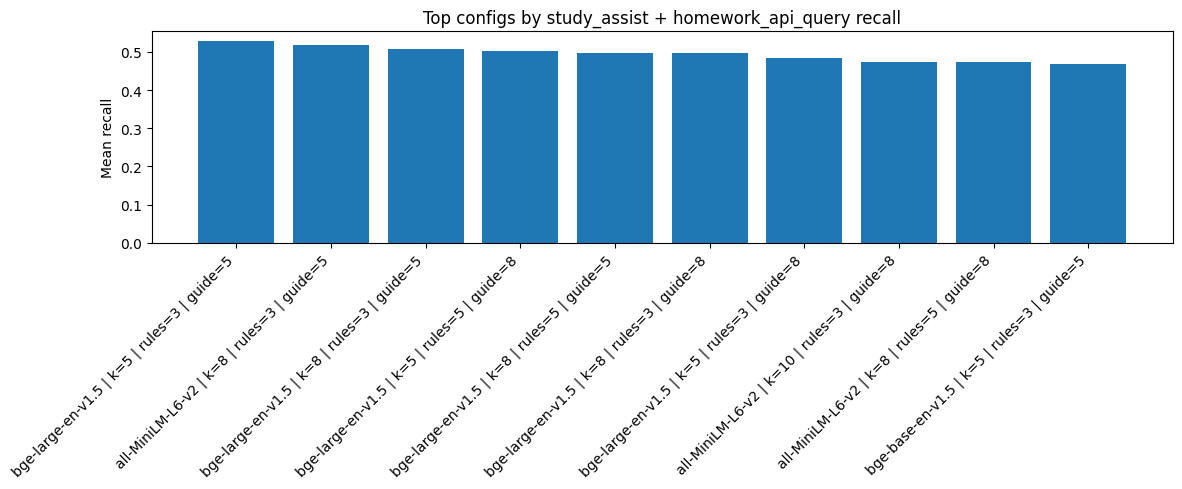

In [104]:
# Cell 11: Plot top configs

import matplotlib.pyplot as plt

plot_df = leaderboard.head(10).copy()

plot_df["config"] = (
    plot_df["embedding_model"].str.replace("BAAI/", "", regex=False)
    + " | k=" + plot_df["top_k"].astype(str)
    + " | rules=" + plot_df["rules_top_k"].astype(str)
    + " | guide=" + plot_df["guidelines_top_k"].astype(str)
)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["config"], plot_df["important_recall_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean recall")
plt.title("Top configs by study_assist + homework_api_query recall")
plt.tight_layout()
plt.show()

In [105]:
# Cell 12: Print conclusion

print("Recommended config:")
print(f"embedding_model  = {best_config['embedding_model']}")
print(f"top_k            = {best_config['top_k']}")
print(f"rules_top_k      = {best_config['rules_top_k']}")
print(f"guidelines_top_k = {best_config['guidelines_top_k']}")
print()
print("Reason:")
print(f"- important_recall_mean = {best_config['important_recall_mean']}")
print(f"- homework_api_recall   = {best_config['homework_api_recall']}")
print(f"- study_assist_recall   = {best_config['study_assist_recall']}")
print("- tie-breaker prefers lower top_k / rules_top_k / guidelines_top_k")

Recommended config:
embedding_model  = BAAI/bge-large-en-v1.5
top_k            = 5
rules_top_k      = 3
guidelines_top_k = 5

Reason:
- important_recall_mean = 0.5274
- homework_api_recall   = 0.6446
- study_assist_recall   = 0.3955
- tie-breaker prefers lower top_k / rules_top_k / guidelines_top_k
